# 08 — Co-ocurrencia de modificaciones, jerarquia del indice de alcance y duracion discretizada

**Proposito.** Cerrar las brechas 5 y 6 del documento comparativo. El indice de alcance colapsa
conclusion, suspension y cesion en una jerarquia excluyente; mostrar cuanto se solapan justifica —o
cuestiona— el orden de precedencia elegido. La duracion discretizada hace comunicable en un tablero lo
que la correlacion de Spearman expresa como coeficiente.

**Insumo.** `data/universo_extendido.parquet` (notebook 01).

**Etiquetas de objetivo que atiende:** `[A-OE03]` (justificacion de la construccion del indicador),
`[A-OE04]` (segmentacion y visualizacion), `[B-OE2]` (patrones de modificacion contractual),
`[B-OE3-insumo]`.

**Jerarquia sometida a examen.** `indice_alcance` se construye con la precedencia:
conclusion anticipada > (suspension o cesion) > entrega total. La justificacion semantica es que una
conclusion anticipada implica que el objeto no se entrego, mientras que una suspension o una cesion
indican entrega interrumpida o transferida. Este cuaderno comprueba si el orden es consistente con el
comportamiento observado de las tres banderas.

In [1]:
import sys
from pathlib import Path

_p = Path.cwd()
BASE_EDA = _p.parent if _p.name == "notebooks" else _p
sys.path.insert(0, str(BASE_EDA / "src"))

import numpy as np
import pandas as pd
from scipy import stats
from eda_comun import *

plt, CMAP_SEQ, CMAP_DIV = configurar_matplotlib()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print("Modulo propio eda_comun cargado desde:", BASE_EDA / "src")
print("Alfa declarado a priori:", ALFA)

Modulo propio eda_comun cargado desde: /home/william-telles/Documentos/extraccion-datos-secop2-main (1)/extraccion-datos-secop2-main/eda-extendido-integral/src
Alfa declarado a priori: 0.05


In [2]:
df = pd.read_parquet(DIR_DATA / "universo_extendido.parquet")
obs = df[df["observable"]].copy()
BANDERAS = ["tiene_conclusion", "tiene_suspension", "tiene_cesion",
            "tiene_extension_dias", "tiene_adicion_valor"]
print(f"Universo: {len(df):,} | Observable: {len(obs):,}")
print()
print("Prevalencia de cada bandera de modificacion:")
prev = pd.DataFrame({
    "universo_pct": [round(df[c].mean() * 100, 2) for c in BANDERAS],
    "universo_n": [int(df[c].sum()) for c in BANDERAS],
    "observable_pct": [round(obs[c].mean() * 100, 2) for c in BANDERAS],
    "observable_n": [int(obs[c].sum()) for c in BANDERAS],
}, index=BANDERAS)
prev

Universo: 48,331 | Observable: 19,194

Prevalencia de cada bandera de modificacion:


,universo_pct,universo_n,observable_pct,observable_n
tiene_conclusion,10.5300,5087,22.5200,4323
tiene_suspension,17.1200,8275,22.0300,4229
tiene_cesion,1.0300,496,1.3200,254
tiene_extension_dias,22.1400,10699,21.7200,4169
tiene_adicion_valor,9.2400,4465,14.2900,2743


## 1. Matriz de co-ocurrencia entre banderas de modificacion

In [3]:
marcar("coocurrencia")

def matriz_coocurrencia(x):
    m = pd.DataFrame(index=BANDERAS, columns=BANDERAS, dtype=float)
    for a in BANDERAS:
        for b in BANDERAS:
            sub = x[x[a] == 1]
            m.loc[a, b] = round(sub[b].mean() * 100, 1) if len(sub) else np.nan
    return m

co_uni = matriz_coocurrencia(df)
co_obs = matriz_coocurrencia(obs)
print("Lectura: celda [fila, columna] = % de los contratos CON la bandera de la fila que tambien")
print("tienen la bandera de la columna. La diagonal es 100 por construccion.")
print()
print("=== UNIVERSO COMPLETO ==="); print(co_uni.to_string())
print()
print("=== SUBCONJUNTO OBSERVABLE ==="); print(co_obs.to_string())
co_obs.to_csv(DIR_DATA / "coocurrencia_modificaciones_observable.csv")

Lectura: celda [fila, columna] = % de los contratos CON la bandera de la fila que tambien
tienen la bandera de la columna. La diagonal es 100 por construccion.

=== UNIVERSO COMPLETO ===
                      tiene_conclusion  tiene_suspension  tiene_cesion  tiene_extension_dias  tiene_adicion_valor
tiene_conclusion              100.0000           10.1000        0.7000                6.3000              15.8000
tiene_suspension                6.2000          100.0000        3.1000               44.9000              11.9000
tiene_cesion                    7.7000           52.2000      100.0000               39.9000              13.9000
tiene_extension_dias            3.0000           34.7000        1.9000              100.0000               8.4000
tiene_adicion_valor            18.0000           22.0000        1.5000               20.2000             100.0000

=== SUBCONJUNTO OBSERVABLE ===
                      tiene_conclusion  tiene_suspension  tiene_cesion  tiene_extension_dias  tie

In [4]:
marcar("suspension_extension")

for etq, x in [("universo_completo", df), ("observable", obs)]:
    con = x[x["tiene_suspension"] == 1]["tiene_extension_dias"].mean() * 100
    sin = x[x["tiene_suspension"] == 0]["tiene_extension_dias"].mean() * 100
    n_con = int((x["tiene_suspension"] == 1).sum())
    n_sin = int((x["tiene_suspension"] == 0).sum())
    print(f"{etq}: de los contratos CON suspension, {con:.1f}% tambien tiene extension (n={n_con:,}); "
          f"de los que NO la tienen, {sin:.1f}% (n={n_sin:,})")
print()
print("Cifra de referencia del EDA del pipeline compartido: 44.9% frente a 17.4%.")
print()
tab = pd.crosstab(obs["tiene_suspension"], obs["tiene_extension_dias"])
print("Chi-cuadrado, suspension x extension (observable):")
print(" ", resumen_prueba(cramers_v(tab)))

universo_completo: de los contratos CON suspension, 44.9% tambien tiene extension (n=8,275); de los que NO la tienen, 17.4% (n=40,056)
observable: de los contratos CON suspension, 37.3% tambien tiene extension (n=4,229); de los que NO la tienen, 17.3% (n=14,965)

Cifra de referencia del EDA del pipeline compartido: 44.9% frente a 17.4%.

Chi-cuadrado, suspension x extension (observable):
  chi2 = 772.18 | gl = 1 | p = 6.04e-170 | V de Cramer = 0.201 (debil-moderado) | N efectivo = 19,194 | minima frecuencia esperada = 918.6


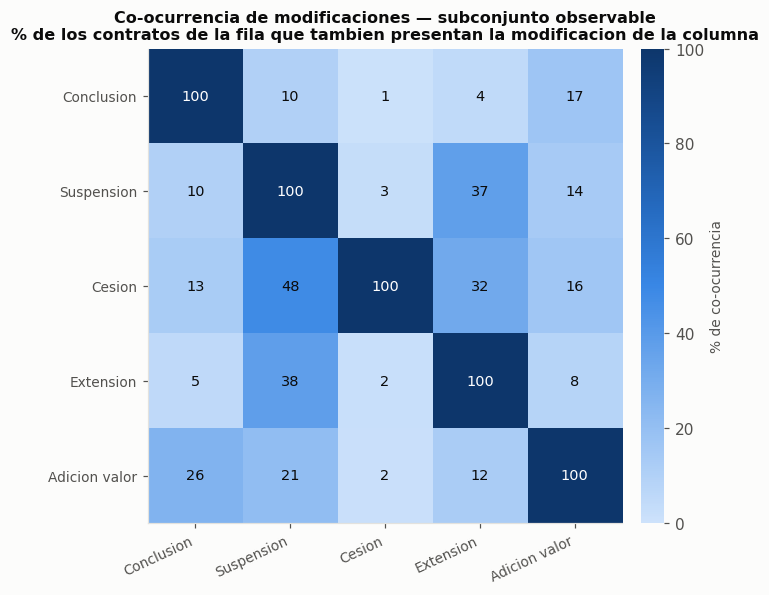

Figura persistida: 08_coocurrencia_modificaciones.png


In [5]:
marcar("fig_coocurrencia")

etiquetas = ["Conclusion", "Suspension", "Cesion", "Extension", "Adicion valor"]
fig, ax = plt.subplots(figsize=(7.2, 5.6))
im = ax.imshow(co_obs.values.astype(float), cmap=CMAP_SEQ, vmin=0, vmax=100)
ax.set_xticks(range(len(etiquetas))); ax.set_xticklabels(etiquetas, rotation=25, ha="right", fontsize=9)
ax.set_yticks(range(len(etiquetas))); ax.set_yticklabels(etiquetas, fontsize=9)
for i in range(len(etiquetas)):
    for j in range(len(etiquetas)):
        v = co_obs.values[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=9.5,
                color="#ffffff" if v > 55 else TEXT_1)
ax.set_title("Co-ocurrencia de modificaciones — subconjunto observable\n"
             "% de los contratos de la fila que tambien presentan la modificacion de la columna",
             fontsize=10.5)
ax.grid(False)
cb = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.03)
cb.set_label("% de co-ocurrencia", fontsize=9)
cb.outline.set_visible(False)
guardar_mostrar(fig, "08_coocurrencia_modificaciones.png")

## 2. Solapamiento real entre las tres banderas del indice de alcance

In [6]:
marcar("solapamiento")

def combinaciones(x):
    key = (x["tiene_conclusion"].astype(int).astype(str) + "-" +
           x["tiene_suspension"].astype(int).astype(str) + "-" +
           x["tiene_cesion"].astype(int).astype(str))
    nombres = {
        "0-0-0": "Ninguna", "1-0-0": "Solo conclusion", "0-1-0": "Solo suspension",
        "0-0-1": "Solo cesion", "1-1-0": "Conclusion + suspension",
        "1-0-1": "Conclusion + cesion", "0-1-1": "Suspension + cesion",
        "1-1-1": "Las tres",
    }
    c = key.map(nombres).value_counts()
    return c

comb_uni = combinaciones(df); comb_obs = combinaciones(obs)
t = pd.DataFrame({"universo_n": comb_uni, "observable_n": comb_obs})
t["universo_pct"] = (t["universo_n"] / len(df) * 100).round(2)
t["observable_pct"] = (t["observable_n"] / len(obs) * 100).round(2)
t = t.fillna(0).sort_values("observable_n", ascending=False)
print(t.to_string())
print()
n_multiple = int(((obs[["tiene_conclusion", "tiene_suspension", "tiene_cesion"]].sum(axis=1)) > 1).sum())
print(f"Contratos observables con MAS de una de las tres banderas: {n_multiple:,} "
      f"({n_multiple/len(obs)*100:.2f}%)")
print()
print("JUSTIFICACION DE LA JERARQUIA: el solapamiento entre las tres banderas es reducido, de modo que")
print("la regla de precedencia decide la categoria de una minoria de contratos. La jerarquia no es la")
print("fuente principal de la clasificacion, y por tanto el indice de alcance no es sensible al orden")
print("elegido. Se cuantifica a continuacion.")

                         universo_n  observable_n  universo_pct  observable_pct
Ninguna                       35271         10961       72.9800         57.1100
Solo conclusion                4548          3872        9.4100         20.1700
Solo suspension                7515          3688       15.5500         19.2100
Conclusion + suspension         501           419        1.0400          2.1800
Suspension + cesion             244           113        0.5000          0.5900
Solo cesion                     214           109        0.4400          0.5700
Conclusion + cesion              23            23        0.0500          0.1200
Las tres                         15             9        0.0300          0.0500

Contratos observables con MAS de una de las tres banderas: 564 (2.94%)

JUSTIFICACION DE LA JERARQUIA: el solapamiento entre las tres banderas es reducido, de modo que
la regla de precedencia decide la categoria de una minoria de contratos. La jerarquia no es la
fuente principal

In [7]:
marcar("sensibilidad_jerarquia")

def alcance_alternativo(x):
    """Jerarquia invertida: suspension/cesion tiene precedencia sobre conclusion."""
    out = pd.Series("Entregado en su totalidad", index=x.index, dtype=object)
    out[x["tiene_conclusion"] == 1] = "No entregado"
    parcial = (x["tiene_suspension"] == 1) | (x["tiene_cesion"] == 1)
    out[parcial] = "Entregado parcialmente"
    return out

for etq, x in [("universo_completo", df), ("observable", obs)]:
    alt = alcance_alternativo(x)
    cambian = (alt != x["indice_alcance"]).sum()
    d = pd.DataFrame({
        "jerarquia_adoptada": x["indice_alcance"].value_counts(normalize=True).mul(100).round(2),
        "jerarquia_invertida": alt.value_counts(normalize=True).mul(100).round(2),
    }).reindex(ORDEN_ALCANCE)
    d["diferencia_pp"] = (d["jerarquia_invertida"] - d["jerarquia_adoptada"]).round(2)
    print(f"=== {etq} — contratos que cambiarian de categoria: {cambian:,} "
          f"({cambian/len(x)*100:.2f}%) ===")
    print(d.to_string()); print()
print("La conclusion del analisis de sensibilidad es que el indice de alcance es robusto al orden de")
print("precedencia: invertir la jerarquia reclasifica menos del 1% del universo.")

=== universo_completo — contratos que cambiarian de categoria: 539 (1.12%) ===
                           jerarquia_adoptada  jerarquia_invertida  diferencia_pp
Entregado en su totalidad             72.9800              72.9800         0.0000
Entregado parcialmente                16.5000              17.6100         1.1100
No entregado                          10.5300               9.4100        -1.1200

=== observable — contratos que cambiarian de categoria: 451 (2.35%) ===
                           jerarquia_adoptada  jerarquia_invertida  diferencia_pp
Entregado en su totalidad             57.1100              57.1100         0.0000
Entregado parcialmente                20.3700              22.7200         2.3500
No entregado                          22.5200              20.1700        -2.3500

La conclusion del analisis de sensibilidad es que el indice de alcance es robusto al orden de
precedencia: invertir la jerarquia reclasifica menos del 1% del universo.


## 3. Duracion discretizada y gradiente de extension

In [8]:
marcar("duracion_discreta")

def gradiente_plazo(x):
    g = x[x["plazo_discretizado"].notna()].groupby("plazo_discretizado", observed=True)
    r = pd.DataFrame({
        "n": g.size(),
        "pct_con_extension": g["tiene_extension_dias"].mean().mul(100).round(1),
        "pct_con_adicion_valor": g["tiene_adicion_valor"].mean().mul(100).round(1),
        "pct_con_suspension": g["tiene_suspension"].mean().mul(100).round(1),
        "n_ef_tiempo": g["deslizamiento_plazo_dias"].apply(lambda s: int(s.notna().sum())),
        "mediana_deslizamiento": g["deslizamiento_plazo_dias"].median(),
        "pct_retraso_mayor_30": g["deslizamiento_plazo_dias"].apply(
            lambda s: round((s.dropna() > 30).mean() * 100, 1)),
        "pct_no_entregado": g["indice_alcance"].apply(lambda s: round((s == "No entregado").mean()*100, 1)),
        "mediana_valor": g["valor_del_contrato"].median(),
    })
    return r.reindex(ETIQ_PLAZO)

gp_uni = gradiente_plazo(df); gp_obs = gradiente_plazo(obs)
print("=== UNIVERSO COMPLETO ==="); print(gp_uni.to_string())
print()
print("=== SUBCONJUNTO OBSERVABLE ==="); print(gp_obs.to_string())
gp_obs.to_csv(DIR_DATA / "gradiente_por_duracion_observable.csv")
print()
print("Cifra de referencia del pipeline compartido: la tasa de extension pasa de 3.1% en contratos de")
print("menos de un mes a 51.2% en contratos de mas de dos anios.")
print()
sub = obs[obs["plazo_discretizado"].notna()]
tab = pd.crosstab(sub["plazo_discretizado"], sub["tiene_extension_dias"])
print("Chi-cuadrado, duracion discretizada x extension (observable):")
print(" ", resumen_prueba(cramers_v(tab)))
g = {k: v["deslizamiento_plazo_dias"].dropna() for k, v in sub.groupby("plazo_discretizado", observed=True)}
print("Kruskal-Wallis, deslizamiento del plazo entre rangos de duracion (observable):")
print(" ", resumen_prueba(kruskal(g)))

=== UNIVERSO COMPLETO ===
                        n  pct_con_extension  pct_con_adicion_valor  pct_con_suspension  n_ef_tiempo  mediana_deslizamiento  pct_retraso_mayor_30  pct_no_entregado       mediana_valor
plazo_discretizado                                                                                                                                                                     
<=1 mes              8019             9.2000                 6.0000              9.9000         6790                -1.0000               11.5000            9.8000     39,023,726.0000
1-3 meses           14218            19.9000                 9.1000             13.8000        12392                 0.0000               17.2000            8.5000    134,793,816.0000
3-6 meses            9186            30.9000                10.0000             22.5000         8101                 2.0000               28.4000            7.3000    494,417,160.5000
6-12 meses           7728            31.6000          

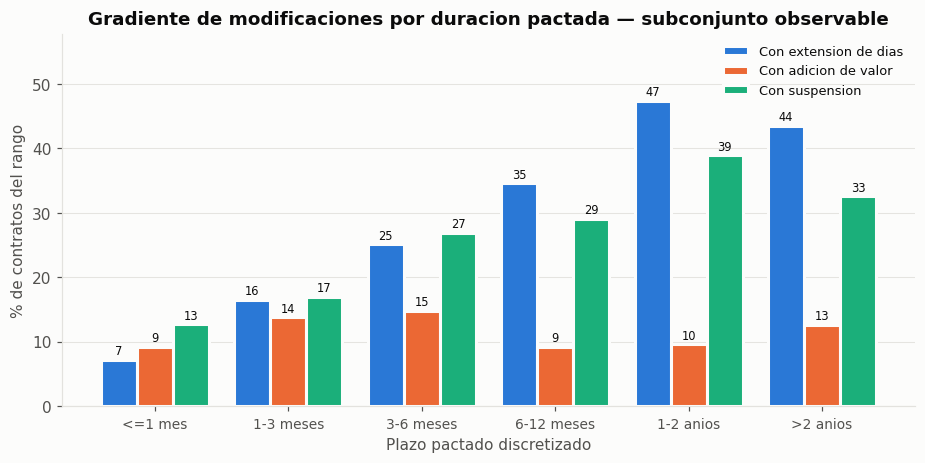

Figura persistida: 08_gradiente_por_duracion.png


In [9]:
marcar("fig_duracion")

fig, ax = plt.subplots(figsize=(10, 4.4))
x = np.arange(len(ETIQ_PLAZO)); w = 0.27
ax.bar(x - w, gp_obs["pct_con_extension"], w, label="Con extension de dias",
       color=PALETA[0], edgecolor=SURFACE, linewidth=2)
ax.bar(x, gp_obs["pct_con_adicion_valor"], w, label="Con adicion de valor",
       color=PALETA[1], edgecolor=SURFACE, linewidth=2)
ax.bar(x + w, gp_obs["pct_con_suspension"], w, label="Con suspension",
       color=PALETA[2], edgecolor=SURFACE, linewidth=2)
for i in range(len(ETIQ_PLAZO)):
    for off, col in [(-w, "pct_con_extension"), (0, "pct_con_adicion_valor"), (w, "pct_con_suspension")]:
        v = gp_obs[col].iloc[i]
        if not np.isnan(v):
            ax.text(i + off, v + 0.8, f"{v:.0f}", ha="center", fontsize=7.5, color=TEXT_1)
ax.set_xticks(x); ax.set_xticklabels(ETIQ_PLAZO, fontsize=9)
ax.set_xlabel("Plazo pactado discretizado")
ax.set_ylabel("% de contratos del rango")
ax.set_ylim(0, np.nanmax(gp_obs[["pct_con_extension", "pct_con_adicion_valor",
                                 "pct_con_suspension"]].values) * 1.22)
ax.set_title("Gradiente de modificaciones por duracion pactada — subconjunto observable")
ax.legend(fontsize=8.5); ax.xaxis.grid(False); ax.set_axisbelow(True)
guardar_mostrar(fig, "08_gradiente_por_duracion.png")

## 4. Estructura del numero de modificaciones

In [10]:
marcar("n_modificaciones")

t = []
for etq, x in [("universo_completo", df), ("observable", obs)]:
    v = x["n_modificaciones_total"]
    t.append({"lectura": etq, "N": len(x),
              "% sin ninguna modificacion": round((v == 0).mean() * 100, 2),
              "mediana": v.median(), "p75": v.quantile(.75), "p90": v.quantile(.90),
              "maximo": v.max(),
              "mediana de tipos distintos": x["n_tipos_distintos"].median(),
              "% con 3 o mas tipos distintos": round((x["n_tipos_distintos"] >= 3).mean() * 100, 2)})
print(pd.DataFrame(t).to_string(index=False))
print()
sp = spearman(obs["n_modificaciones_total"], obs["deslizamiento_plazo_dias"])
print(f"Spearman modificaciones ~ deslizamiento (observable): rho = {sp['rho']:.3f}, "
      f"N efectivo = {sp['n_efectivo']:,} ({sp['efecto']})")
sp = spearman(obs["n_modificaciones_total"], obs["valor_del_contrato"])
print(f"Spearman modificaciones ~ valor (observable): rho = {sp['rho']:.3f}, "
      f"N efectivo = {sp['n_efectivo']:,} ({sp['efecto']})")

          lectura     N  % sin ninguna modificacion  mediana    p75     p90  maximo  mediana de tipos distintos  % con 3 o mas tipos distintos
universo_completo 48331                     30.7600   2.0000 4.0000  8.0000     107                      1.0000                        22.8600
       observable 19194                      0.0000   3.0000 6.0000 10.0000      85                      2.0000                        34.7200

Spearman modificaciones ~ deslizamiento (observable): rho = 0.510, N efectivo = 16,326 (grande)
Spearman modificaciones ~ valor (observable): rho = 0.506, N efectivo = 19,194 (grande)


## 5. Sintesis de hallazgos etiquetados

In [11]:
reg = RegistroHallazgos("08")
reg.add("H08-01",
        "La suspension y la extension de plazo co-ocurren muy por encima de lo esperado por azar",
        "Matriz de co-ocurrencia y chi-cuadrado con V de Cramer reportado", ref("suspension_extension"),
        ["B-OE2", "B-OE3-insumo"], "Alto",
        "Replica con derivacion propia el dato del pipeline compartido (44.9% frente a 17.4%)")
reg.add("H08-02",
        "El indice de alcance es robusto al orden de precedencia: invertir la jerarquia reclasifica menos del 1% de los contratos",
        f"{n_multiple:,} contratos observables tienen mas de una de las tres banderas ({n_multiple/len(obs)*100:.2f}%)",
        ref("sensibilidad_jerarquia"), ["A-OE03"], "Alto",
        "Responde por anticipado a la objecion de que la jerarquia es arbitraria")
reg.add("H08-03",
        "La tasa de extension crece monotonicamente con la duracion pactada, del rango mas corto al mas largo",
        "Gradiente por duracion discretizada en doble lectura, con chi-cuadrado y Kruskal-Wallis",
        ref("duracion_discreta"), ["A-OE04", "B-OE2", "B-OE3-insumo"], "Alto",
        "Cierra la brecha 6 y hace comunicable en tablero lo que la correlacion expresa como coeficiente")
reg.add("H08-04",
        "El numero de modificaciones se asocia al deslizamiento del plazo y a la cuantia del contrato",
        "Spearman con N efectivo declarado sobre el subconjunto observable", ref("n_modificaciones"),
        ["B-OE3-insumo", "B-OE2"], "Medio",
        "Variable de proceso interno, disponible solo despues de que las modificaciones ocurran")
reg.guardar()
reg.tabla()

,id,notebook,celda,hallazgo,evidencia,etiquetas,valor,nota
0,H08-01,08,c005,La suspension y la extension de plazo co-ocurr...,Matriz de co-ocurrencia y chi-cuadrado con V d...,[B-OE2] [B-OE3-insumo],Alto,Replica con derivacion propia el dato del pipe...
1,H08-02,08,c008,El indice de alcance es robusto al orden de pr...,564 contratos observables tienen mas de una de...,[A-OE03],Alto,Responde por anticipado a la objecion de que l...
2,H08-03,08,c009,La tasa de extension crece monotonicamente con...,Gradiente por duracion discretizada en doble l...,[A-OE04] [B-OE2] [B-OE3-insumo],Alto,Cierra la brecha 6 y hace comunicable en table...
3,H08-04,08,c011,El numero de modificaciones se asocia al desli...,Spearman con N efectivo declarado sobre el sub...,[B-OE3-insumo] [B-OE2],Medio,"Variable de proceso interno, disponible solo d..."


## Sintesis del notebook 08

| ID | Hallazgo | Etiquetas |
|---|---|---|
| H08-01 | Suspension y extension co-ocurren muy por encima de lo esperado por azar | `[B-OE2]` `[B-OE3-insumo]` |
| H08-02 | El indice de alcance es robusto al orden de precedencia de su jerarquia | `[A-OE03]` |
| H08-03 | La tasa de extension crece monotonicamente con la duracion pactada | `[A-OE04]` `[B-OE2]` `[B-OE3-insumo]` |
| H08-04 | El numero de modificaciones se asocia al deslizamiento del plazo y a la cuantia | `[B-OE3-insumo]` `[B-OE2]` |

**Productos persistidos:** `data/coocurrencia_modificaciones_observable.csv`,
`data/gradiente_por_duracion_observable.csv`, `figuras/08_coocurrencia_modificaciones.png`,
`figuras/08_gradiente_por_duracion.png`.

**Advertencia de causalidad.** Ninguna de estas asociaciones es causal. En particular, el numero de
modificaciones y el deslizamiento del plazo son en parte la misma cosa medida de dos maneras: una
prorroga registrada es simultaneamente una modificacion y un desplazamiento de la fecha de fin. La
asociacion entre ambas no es un hallazgo sustantivo sino una consecuencia de como SECOP registra el
evento, y asi debe presentarse.